# DAPO AIME pass@k plots

This notebook pulls selected DAPO runs from W&B project `ai2-llm/open_instruct_internal`, plots `eval/math_aime_2025/pass_at_1` over training steps, and plots final `eval/math_aime_2025/pass_at_k` curves for the initial eval and each training run. The initial point at `Step == 0` comes from run `k3kgf1up`.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import re

from datasets import load_dataset
from IPython.display import Markdown
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import wandb

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install it in the active environment before running.") from exc

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
PROJECT_PATH = "ai2-llm/open_instruct_internal"
AIME_METRIC_PREFIX = "eval/math_aime_2025"
PASS_AT_1_KEY = f"{AIME_METRIC_PREFIX}/pass_at_1"
INITIAL_RUN_ID = "k3kgf1up"
INITIAL_RUN_NAME = "initial_eval"

RUNS = [
    {"run_id": "kfk9fxj5", "setting": "N=16, K=8", "N": 16, "K": 8},
    {"run_id": "dm59ak42", "setting": "N=8, K=16", "N": 8, "K": 16},
    {"run_id": "2i7owuys", "setting": "N=4, K=32", "N": 4, "K": 32},
    {"run_id": "os1kcy0m", "setting": "N=2, K=64", "N": 2, "K": 64, "final_eval_run_id": "ubuz9o5q"},
]
RUN_IDS = [run["run_id"] for run in RUNS]
SETTING_ORDER = [run["setting"] for run in RUNS]

STEP_BIN = 100
MAX_STEP = 1000
REPO_OR_NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = (REPO_OR_NOTEBOOK_DIR if REPO_OR_NOTEBOOK_DIR.name == "notebooks" else REPO_OR_NOTEBOOK_DIR / "notebooks") / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

api = wandb.Api(timeout=90)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mnoukhov/.netrc.


## Pull W&B runs

In [3]:
def normalized_step(step: int | float, *, bin_size: int = STEP_BIN) -> int:
    return int(round(float(step) / bin_size) * bin_size)


def load_run_metadata(run_specs: list[dict[str, object]]) -> tuple[pd.DataFrame, dict[str, wandb.apis.public.Run]]:
    rows = []
    run_by_id = {}
    for spec in run_specs:
        run = api.run(f"{PROJECT_PATH}/{spec['run_id']}")
        run_by_id[run.id] = run
        final_eval_run_id = spec.get("final_eval_run_id")
        if final_eval_run_id is not None:
            run_by_id[final_eval_run_id] = api.run(f"{PROJECT_PATH}/{final_eval_run_id}")
        rows.append(
            {
                **spec,
                "run_name": run.name,
                "state": run.state,
                "created_at": run.created_at,
                "url": run.url,
            }
        )

    initial_run = api.run(f"{PROJECT_PATH}/{INITIAL_RUN_ID}")
    run_by_id[INITIAL_RUN_ID] = initial_run
    runs_df = pd.DataFrame(rows)
    runs_df["setting"] = pd.Categorical(runs_df["setting"], categories=SETTING_ORDER, ordered=True)
    return runs_df.sort_values("setting").reset_index(drop=True), run_by_id


def download_pass_at_1_history(
    run: wandb.apis.public.Run,
    *,
    setting: str,
    include_initial: bool = False,
    fixed_step: int | None = None,
) -> pd.DataFrame:
    rows = []
    for row in run.scan_history(keys=["_step", PASS_AT_1_KEY], page_size=1000):
        value = row.get(PASS_AT_1_KEY)
        if value is None:
            continue
        raw_step = int(row.get("_step", row.get("Step", 0)))
        rows.append(
            {
                "run_id": run.id,
                "run_name": INITIAL_RUN_NAME if include_initial else run.name,
                "setting": setting,
                "raw_step": raw_step,
                "Step": fixed_step if fixed_step is not None else 0 if include_initial else normalized_step(raw_step),
                "metric_key": PASS_AT_1_KEY,
                "value": float(value),
            }
        )
    history = pd.DataFrame(rows)
    if history.empty:
        return history
    return history.sort_values(["Step", "raw_step"]).groupby(["run_id", "run_name", "setting", "Step", "metric_key"], as_index=False).agg(
        value=("value", "last"),
        raw_step=("raw_step", "last"),
    )


def collect_pass_at_1_histories(runs_df: pd.DataFrame, run_by_id: dict[str, wandb.apis.public.Run]) -> pd.DataFrame:
    histories = []
    initial_run = run_by_id[INITIAL_RUN_ID]
    for run_row in runs_df.itertuples(index=False):
        history = download_pass_at_1_history(run_by_id[run_row.run_id], setting=run_row.setting)
        print(f"{run_row.run_id}: downloaded {len(history):,} pass@1 rows")
        histories.append(history)

        final_eval_run_id = getattr(run_row, "final_eval_run_id", None)
        if pd.notna(final_eval_run_id):
            final_eval_history = download_pass_at_1_history(run_by_id[final_eval_run_id], setting=run_row.setting, fixed_step=MAX_STEP)
            print(f"{final_eval_run_id}: downloaded {len(final_eval_history):,} final pass@1 rows")
            histories.append(final_eval_history)

        initial_history = download_pass_at_1_history(initial_run, setting=run_row.setting, include_initial=True)
        if not initial_history.empty:
            histories.append(initial_history.tail(1))

    history_df = pd.concat([history for history in histories if not history.empty], ignore_index=True)
    history_df = history_df[(history_df["Step"] >= 0) & (history_df["Step"] <= MAX_STEP)].copy()
    history_df["setting"] = pd.Categorical(history_df["setting"], categories=SETTING_ORDER, ordered=True)
    return history_df.sort_values(["setting", "Step", "run_id"]).reset_index(drop=True)


def pass_at_k_summary_rows(run: wandb.apis.public.Run, *, label: str, setting_order: list[str]) -> list[dict[str, object]]:
    rows = []
    for key, value in run.summary.items():
        match = re.fullmatch(rf"{re.escape(AIME_METRIC_PREFIX)}/pass_at_(\d+)", key)
        if match is None or value is None:
            continue
        rows.append({"run_id": run.id, "setting": label, "k": int(match.group(1)), "value": float(value), "metric_key": key})
    return sorted(rows, key=lambda row: row["k"])


def collect_final_pass_at_k(runs_df: pd.DataFrame, run_by_id: dict[str, wandb.apis.public.Run]) -> pd.DataFrame:
    rows = pass_at_k_summary_rows(run_by_id[INITIAL_RUN_ID], label=INITIAL_RUN_NAME, setting_order=SETTING_ORDER)
    for run_row in runs_df.itertuples(index=False):
        final_eval_run_id = getattr(run_row, "final_eval_run_id", None)
        pass_at_k_run_id = final_eval_run_id if pd.notna(final_eval_run_id) else run_row.run_id
        rows.extend(pass_at_k_summary_rows(run_by_id[pass_at_k_run_id], label=run_row.setting, setting_order=SETTING_ORDER))

    pass_at_k_df = pd.DataFrame(rows)
    if pass_at_k_df.empty:
        raise ValueError("No final pass@k summary metrics were found.")
    label_order = [INITIAL_RUN_NAME, *SETTING_ORDER]
    pass_at_k_df["setting"] = pd.Categorical(pass_at_k_df["setting"], categories=label_order, ordered=True)
    return pass_at_k_df.sort_values(["setting", "k"]).reset_index(drop=True)

In [4]:
runs_df, run_by_id = load_run_metadata(RUNS)
pass_at_1_df = collect_pass_at_1_histories(runs_df, run_by_id)
pass_at_k_df = collect_final_pass_at_k(runs_df, run_by_id)

display(runs_df)
display(pass_at_1_df.head())
display(pass_at_k_df)

kfk9fxj5: downloaded 10 pass@1 rows


dm59ak42: downloaded 10 pass@1 rows


2i7owuys: downloaded 10 pass@1 rows


os1kcy0m: downloaded 9 pass@1 rows


ubuz9o5q: downloaded 1 final pass@1 rows


,run_id,setting,N,K,run_name,state,created_at,url,final_eval_run_id
0,kfk9fxj5,"N=16, K=8",16,8,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,finished,2026-05-04T22:37:20Z,https://wandb.ai/ai2-llm/open_instruct_interna...,NaN
1,dm59ak42,"N=8, K=16",8,16,qwen3_4b_base_dapo_baseline_async4__1__1777915407,finished,2026-05-04T17:23:30Z,https://wandb.ai/ai2-llm/open_instruct_interna...,NaN
2,2i7owuys,"N=4, K=32",4,32,qwen3_4b_base_dapo_baseline_async4_n4_k32__1__...,finished,2026-05-04T22:44:48Z,https://wandb.ai/ai2-llm/open_instruct_interna...,NaN
3,os1kcy0m,"N=2, K=64",2,64,qwen3_4b_base_dapo_baseline_async4_n2_k64__1__...,finished,2026-05-05T01:36:15Z,https://wandb.ai/ai2-llm/open_instruct_interna...,ubuz9o5q


,run_id,run_name,setting,Step,metric_key,value,raw_step
0,k3kgf1up,initial_eval,"N=16, K=8",0,eval/math_aime_2025/pass_at_1,0.051618,1
1,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",100,eval/math_aime_2025/pass_at_1,0.085100,105
2,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",200,eval/math_aime_2025/pass_at_1,0.132254,204
3,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",300,eval/math_aime_2025/pass_at_1,0.133929,303
4,kfk9fxj5,qwen3_4b_base_dapo_baseline_async4_n16_k8__1__...,"N=16, K=8",400,eval/math_aime_2025/pass_at_1,0.157227,402


,run_id,setting,k,value,metric_key
0,k3kgf1up,initial_eval,1,0.051618,eval/math_aime_2025/pass_at_1
1,k3kgf1up,initial_eval,2,0.090915,eval/math_aime_2025/pass_at_2
2,k3kgf1up,initial_eval,4,0.144381,eval/math_aime_2025/pass_at_4
3,k3kgf1up,initial_eval,8,0.199415,eval/math_aime_2025/pass_at_8
4,k3kgf1up,initial_eval,16,0.247789,eval/math_aime_2025/pass_at_16
5,k3kgf1up,initial_eval,32,0.294643,eval/math_aime_2025/pass_at_32
6,kfk9fxj5,"N=16, K=8",1,0.190290,eval/math_aime_2025/pass_at_1
7,kfk9fxj5,"N=16, K=8",2,0.230541,eval/math_aime_2025/pass_at_2
8,kfk9fxj5,"N=16, K=8",4,0.277895,eval/math_aime_2025/pass_at_4
9,kfk9fxj5,"N=16, K=8",8,0.338008,eval/math_aime_2025/pass_at_8


## Plot eval/math_aime_2025/pass_at_1

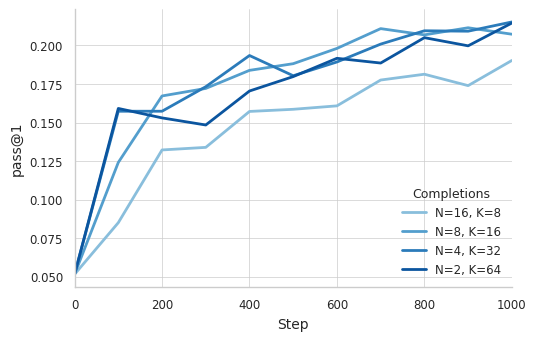

In [5]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Blues",
    font="DejaVu Sans",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8.5,
        "legend.title_fontsize": 9,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.linewidth": 0.5,
        "lines.linewidth": 2.0,
    },
)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(5.25, 3.3), constrained_layout=True)
blue_palette = dict(zip(SETTING_ORDER, sns.color_palette("Blues", n_colors=len(SETTING_ORDER) + 2)[2:]))

sns.lineplot(
    data=pass_at_1_df,
    x="Step",
    y="value",
    hue="setting",
    hue_order=SETTING_ORDER,
    palette=blue_palette,
    estimator=None,
    ax=ax,
)

ax.set_xlabel("Step")
ax.set_ylabel("pass@1")
ax.set_xlim(0, MAX_STEP)
ax.set_xticks(range(0, MAX_STEP + STEP_BIN, 200))
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Completions", frameon=False, loc="best")
sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR / "dapo_aime_2025_pass_at_1.pdf", bbox_inches="tight")

## Plot final eval/math_aime_2025/pass_at_k

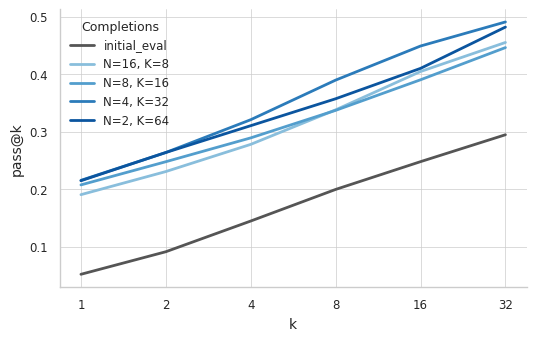

In [6]:
fig, ax = plt.subplots(figsize=(5.25, 3.3), constrained_layout=True)
label_order = [INITIAL_RUN_NAME, *SETTING_ORDER]
palette = {INITIAL_RUN_NAME: "#555555", **blue_palette}

sns.lineplot(
    data=pass_at_k_df,
    x="k",
    y="value",
    hue="setting",
    hue_order=label_order,
    palette=palette,
    estimator=None,
    ax=ax,
)

ks = sorted(pass_at_k_df["k"].unique())
ax.set_xlabel("k")
ax.set_ylabel("pass@k")
ax.set_xscale("log", base=2)
ax.set_xticks(ks)
ax.set_xticklabels([str(k) for k in ks])
ax.legend(title="Completions", frameon=False, loc="best")
sns.despine(ax=ax)

fig.savefig(OUTPUT_DIR / "dapo_aime_2025_final_pass_at_k.pdf", bbox_inches="tight")

## Plot prompt difficulty distributions

In [7]:
DPO_MATH_DATASET_REPO = "mnoukhov/dapo-math-17k-processed-filtered-qwen3-4b-base-32samples-quartiles"
DPO_MATH_DATASET_SPLIT = "train"
DPO_MATH_NUM_SAMPLES = 32


def estimate_pass_at_k(num_samples: int, num_correct: int, k: int) -> float:
    """Estimate pass@k for one prompt."""
    if num_samples < 1:
        raise ValueError(f"num_samples must be >= 1, got {num_samples}.")
    if not (0 <= num_correct <= num_samples):
        raise ValueError(
            f"num_correct must satisfy 0 <= num_correct <= num_samples, got {num_correct} with {num_samples}."
        )
    if not (1 <= k <= num_samples):
        raise ValueError(f"k must satisfy 1 <= k <= num_samples, got {k} with {num_samples}.")
    if num_samples - num_correct < k:
        return 1.0
    return 1.0 - (math.comb(num_samples - num_correct, k) / math.comb(num_samples, k))


difficulty_df = load_dataset(DPO_MATH_DATASET_REPO, split=DPO_MATH_DATASET_SPLIT).to_pandas()
difficulty_df["pass_count"] = pd.to_numeric(difficulty_df["pass_count"], errors="raise").astype(int)
difficulty_df["num_samples"] = pd.to_numeric(difficulty_df["num_samples"], errors="raise").astype(int)

if not (difficulty_df["num_samples"] == DPO_MATH_NUM_SAMPLES).all():
    observed_num_samples = sorted(difficulty_df["num_samples"].unique())
    raise ValueError(f"Expected all prompts to have {DPO_MATH_NUM_SAMPLES} samples, got {observed_num_samples}.")

difficulty_df["pass_at_32"] = difficulty_df["pass_count"] / DPO_MATH_NUM_SAMPLES



,pass_count,num_examples
0,0,3664
1,1,1389
2,2,975
3,3,705
4,4,655
5,5,515
6,6,496
7,7,380
8,8,367
9,9,357


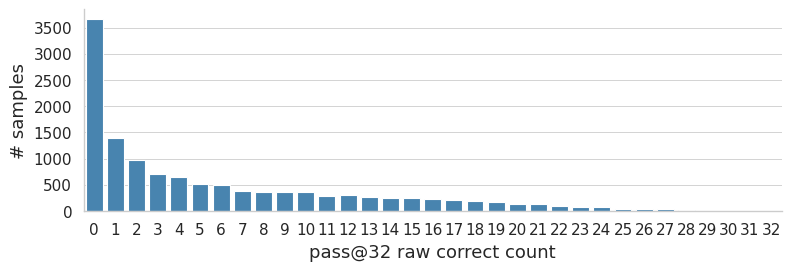

In [8]:
pass_at_32_counts_df = difficulty_df.groupby("pass_count", as_index=False).size().rename(columns={"size": "num_examples"})
plot_df = pd.DataFrame({"pass_count": list(range(DPO_MATH_NUM_SAMPLES + 1))}).merge(
    pass_at_32_counts_df,
    on="pass_count",
    how="left",
)
plot_df["num_examples"] = plot_df["num_examples"].fillna(0).astype(int)

with mpl.rc_context(
    {
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "grid.linewidth": 0.6,
    }
):
    fig, ax = plt.subplots(figsize=(7.8, 2.6), constrained_layout=True)
    sns.barplot(data=plot_df, x="pass_count", y="num_examples", color=sns.color_palette("Blues", n_colors=5)[3], ax=ax)

    ax.set_xlabel("pass@32 raw correct count")
    ax.set_ylabel("# samples")
    ax.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax)

    fig.savefig(OUTPUT_DIR / "dapo_math_prompt_difficulty_pass_at_32_counts.pdf", bbox_inches="tight")

display(plot_df)



## Plot AIME difficulty-bucketed final accuracy

Use `eval/prompt_solve_rate_by_index_table` from a 64-sample initial-model eval (run `w47m67sf`) to bucket AIME prompts into three difficulty categories:

- `hard`: pass@64 == 0 (solve_rate == 0) on the initial model.
- `easy` / `medium`: the remaining prompts split evenly by initial solve_rate (highest -> easy, lowest -> medium).

Then compare the per-bucket pass@1 for the initial model and each of the four trained settings using each run's final `eval/prompt_solve_rate_by_index_table`.

In [9]:
import json
import tempfile

EVAL_TABLE_KEY = "eval/prompt_solve_rate_by_index_table"
AIME_NUM_SAMPLES = 32
DIFFICULTY_RUN_ID = "w47m67sf"
DIFFICULTY_NUM_SAMPLES = 64
DIFFICULTY_ORDER = ["hard", "medium", "easy"]
BUCKET_SETTING_ORDER = [s for s in SETTING_ORDER if s != "N=16, K=8"]


def _table_path_from_entry(entry) -> str:
    if isinstance(entry, dict) and "path" in entry:
        return entry["path"]
    return getattr(entry, "path", None) or entry["_path"]


def _read_table_file(run: wandb.apis.public.Run, table_path: str) -> pd.DataFrame:
    with tempfile.TemporaryDirectory() as tmp_dir:
        downloaded = run.file(table_path).download(root=tmp_dir, replace=True)
        with open(downloaded.name, "r") as fh:
            payload = json.load(fh)
    table_df = pd.DataFrame(payload["data"], columns=payload["columns"])
    table_df["dataset_index"] = pd.to_numeric(table_df["dataset_index"], errors="raise").astype(int)
    table_df["solve_rate"] = pd.to_numeric(table_df["solve_rate"], errors="raise").astype(float)
    return table_df.sort_values("dataset_index").reset_index(drop=True)


def _load_solve_rate_table(run: wandb.apis.public.Run, *, table_key: str = EVAL_TABLE_KEY) -> pd.DataFrame:
    """Download the latest logged W&B Table for `table_key` and return a DataFrame."""
    summary_entry = run.summary.get(table_key)
    if summary_entry is None:
        raise KeyError(f"Run {run.id} has no summary entry for {table_key!r}.")
    return _read_table_file(run, _table_path_from_entry(summary_entry))


def _load_solve_rate_table_at_step(
    run: wandb.apis.public.Run, step: int, *, table_key: str = EVAL_TABLE_KEY, tolerant: bool = False
) -> pd.DataFrame:
    """Download the W&B Table for `table_key` logged at `_step == step` (or nearest if tolerant)."""
    candidates: list[tuple[int, object]] = []
    for row in run.scan_history(keys=["_step", table_key], page_size=1000):
        entry = row.get(table_key)
        if entry is None:
            continue
        candidates.append((int(row.get("_step", -1)), entry))
    if not candidates:
        raise KeyError(f"Run {run.id} has no {table_key!r} entries with a _step.")
    exact = [entry for s, entry in candidates if s == int(step)]
    if exact:
        chosen = exact[-1]
    elif tolerant:
        chosen_step, chosen = min(candidates, key=lambda pair: abs(pair[0] - int(step)))
        print(f"Run {run.id}: no exact step {step} for {table_key!r}; using nearest step {chosen_step}.")
    else:
        steps_seen = sorted({s for s, _ in candidates})
        raise KeyError(f"Run {run.id} has no {table_key!r} at step {step} (saw steps {steps_seen}).")
    return _read_table_file(run, _table_path_from_entry(chosen))


difficulty_run = api.run(f"{PROJECT_PATH}/{DIFFICULTY_RUN_ID}")
run_by_id[DIFFICULTY_RUN_ID] = difficulty_run

initial_solve_df = _load_solve_rate_table(difficulty_run)
initial_solve_df["pass_count"] = (initial_solve_df["solve_rate"] * DIFFICULTY_NUM_SAMPLES).round().astype(int)
print(f"AIME prompts in difficulty eval ({DIFFICULTY_RUN_ID}, n={DIFFICULTY_NUM_SAMPLES}): {len(initial_solve_df)}")
display(initial_solve_df.head())

AIME prompts in difficulty eval (w47m67sf, n=64): 60


,dataset_index,solve_rate,pass_count
0,0,0.515625,33
1,1,0.500000,32
2,2,0.328125,21
3,3,0.218750,14
4,4,0.187500,12


,pass_count,num_examples
0,0,33
1,1,4
2,2,2
3,3,1
4,4,0
...,...,...
60,60,1
61,61,0
62,62,0
63,63,0


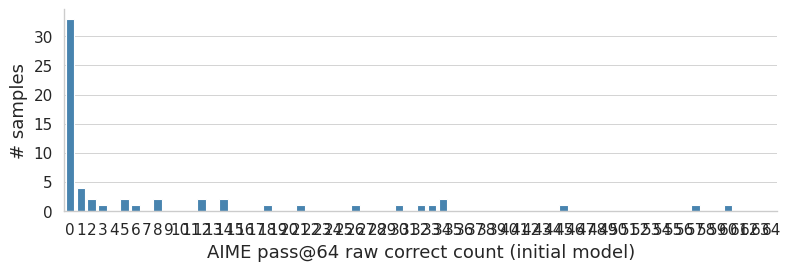

In [10]:
aime_pass_count_df = (
    pd.DataFrame({"pass_count": list(range(DIFFICULTY_NUM_SAMPLES + 1))})
    .merge(
        initial_solve_df.groupby("pass_count", as_index=False).size().rename(columns={"size": "num_examples"}),
        on="pass_count",
        how="left",
    )
)
aime_pass_count_df["num_examples"] = aime_pass_count_df["num_examples"].fillna(0).astype(int)

with mpl.rc_context(
    {
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "grid.linewidth": 0.6,
    }
):
    fig, ax = plt.subplots(figsize=(7.8, 2.6), constrained_layout=True)
    sns.barplot(
        data=aime_pass_count_df,
        x="pass_count",
        y="num_examples",
        color=sns.color_palette("Blues", n_colors=5)[3],
        ax=ax,
    )
    ax.set_xlabel(f"AIME pass@{DIFFICULTY_NUM_SAMPLES} raw correct count (initial model)")
    ax.set_ylabel("# samples")
    ax.tick_params(axis="x", rotation=0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / f"dapo_aime_2025_initial_pass_at_{DIFFICULTY_NUM_SAMPLES}_counts.pdf", bbox_inches="tight")

display(aime_pass_count_df)

In [11]:
def assign_difficulty_buckets(initial_df: pd.DataFrame) -> pd.DataFrame:
    """Bucket AIME prompts using initial-model solve rates.

    - hard: solve_rate == 0
    - remaining prompts split evenly into easy (highest solve_rate half) and medium (lower half).
    """
    df = initial_df.copy()
    hard_mask = df["solve_rate"] <= 0
    df.loc[hard_mask, "difficulty"] = "hard"

    remainder = df.loc[~hard_mask].sort_values("solve_rate", ascending=False).reset_index(drop=True)
    n_remainder = len(remainder)
    n_easy = n_remainder // 2 + (n_remainder % 2)
    easy_indices = remainder.loc[: n_easy - 1, "dataset_index"].tolist()
    medium_indices = remainder.loc[n_easy:, "dataset_index"].tolist()
    df.loc[df["dataset_index"].isin(easy_indices), "difficulty"] = "easy"
    df.loc[df["dataset_index"].isin(medium_indices), "difficulty"] = "medium"
    df["difficulty"] = pd.Categorical(df["difficulty"], categories=DIFFICULTY_ORDER, ordered=True)
    return df


difficulty_assignments_df = assign_difficulty_buckets(initial_solve_df)
print(difficulty_assignments_df["difficulty"].value_counts().reindex(DIFFICULTY_ORDER))
display(difficulty_assignments_df.head())

difficulty
hard      33
medium    13
easy      14
Name: count, dtype: int64


,dataset_index,solve_rate,pass_count,difficulty
0,0,0.515625,33,easy
1,1,0.500000,32,easy
2,2,0.328125,21,easy
3,3,0.218750,14,easy
4,4,0.187500,12,medium


In [12]:
def collect_final_solve_rates(
    runs_df: pd.DataFrame,
    run_by_id: dict[str, wandb.apis.public.Run],
    difficulty_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    initial_table = difficulty_df[["dataset_index", "solve_rate", "difficulty"]].copy()
    initial_table["setting"] = INITIAL_RUN_NAME
    rows.append(initial_table)

    diff_lookup = difficulty_df.set_index("dataset_index")["difficulty"]
    for run_row in runs_df.itertuples(index=False):
        if str(run_row.setting) not in BUCKET_SETTING_ORDER:
            continue
        final_eval_run_id = getattr(run_row, "final_eval_run_id", None)
        source_run_id = final_eval_run_id if pd.notna(final_eval_run_id) else run_row.run_id
        run = run_by_id[source_run_id]
        try:
            table_df = _load_solve_rate_table(run)
        except KeyError as exc:
            print(f"skipping {run_row.setting}: {exc}")
            continue
        table_df["setting"] = run_row.setting
        table_df["difficulty"] = table_df["dataset_index"].map(diff_lookup).astype(
            pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
        )
        rows.append(table_df[["dataset_index", "solve_rate", "difficulty", "setting"]])

    final_df = pd.concat(rows, ignore_index=True)
    label_order = [INITIAL_RUN_NAME, *BUCKET_SETTING_ORDER]
    final_df["setting"] = pd.Categorical(final_df["setting"], categories=label_order, ordered=True)
    return final_df


final_solve_rates_df = collect_final_solve_rates(runs_df, run_by_id, difficulty_assignments_df)
bucket_accuracy_df = (
    final_solve_rates_df.groupby(["setting", "difficulty"], observed=True)["solve_rate"]
    .mean()
    .reset_index()
    .rename(columns={"solve_rate": "pass_at_1"})
)
display(bucket_accuracy_df)

,setting,difficulty,pass_at_1
0,initial_eval,hard,0.000000
1,initial_eval,medium,0.066106
2,initial_eval,easy,0.479911
3,"N=8, K=16",hard,0.050189
4,"N=8, K=16",medium,0.175481
5,"N=8, K=16",easy,0.816964
6,"N=4, K=32",hard,0.042614
7,"N=4, K=32",medium,0.185096
8,"N=4, K=32",easy,0.848214
9,"N=2, K=64",hard,0.040720


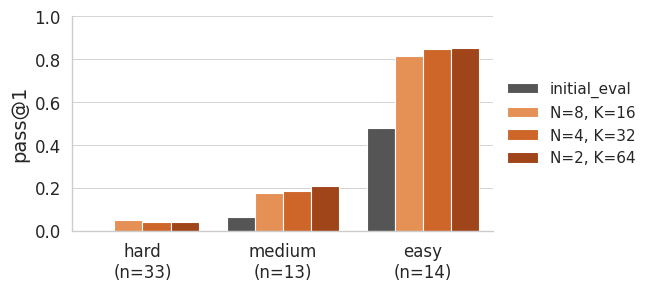

In [13]:
label_order = [INITIAL_RUN_NAME, *BUCKET_SETTING_ORDER]
bucket_n_palette = dict(
    zip(BUCKET_SETTING_ORDER, sns.color_palette("Oranges", n_colors=len(BUCKET_SETTING_ORDER) + 2)[2:])
)
bucket_palette = {INITIAL_RUN_NAME: "#555555", **bucket_n_palette}
difficulty_counts = difficulty_assignments_df["difficulty"].value_counts().reindex(DIFFICULTY_ORDER).astype(int)
difficulty_tick_labels = [f"{d}\n(n={difficulty_counts[d]})" for d in DIFFICULTY_ORDER]

with mpl.rc_context(
    {
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "grid.linewidth": 0.6,
    }
):
    fig, ax = plt.subplots(figsize=(6.4, 2.8), constrained_layout=True)
    sns.barplot(
        data=bucket_accuracy_df,
        x="difficulty",
        y="pass_at_1",
        hue="setting",
        hue_order=label_order,
        palette=bucket_palette,
        order=DIFFICULTY_ORDER,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels)
    ax.set_ylabel("pass@1")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / "dapo_aime_2025_pass_at_1_by_difficulty.pdf", bbox_inches="tight")

## Add NGU K=16 to the difficulty bar plot

In [14]:
NGU_VARIANTS = [
    {"run_id": "b0pb0g1l", "label": "NGU p=0.5", "color": "#9ecae1", "step": None},
    {"run_id": "405xye1i", "label": "NGU p=0.75", "color": "#3182bd", "step": 903},
    {"run_id": "3lc0ftsd", "label": "NGU p=0.9", "color": "#08306b", "step": 800, "tolerant": True},
]

diff_lookup = difficulty_assignments_df.set_index("dataset_index")["difficulty"]
ngu_bucket_frames = []
for variant in NGU_VARIANTS:
    ngu_run = api.run(f"{PROJECT_PATH}/{variant['run_id']}")
    run_by_id[variant["run_id"]] = ngu_run
    if variant["step"] is None:
        ngu_table_df = _load_solve_rate_table(ngu_run)
        step_desc = "summary"
    else:
        ngu_table_df = _load_solve_rate_table_at_step(
            ngu_run, variant["step"], tolerant=variant.get("tolerant", False)
        )
        step_desc = f"step ~{variant['step']}" if variant.get("tolerant") else f"step {variant['step']}"
    ngu_table_df["setting"] = variant["label"]
    ngu_table_df["difficulty"] = ngu_table_df["dataset_index"].map(diff_lookup).astype(
        pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
    )
    bucket = (
        ngu_table_df.groupby("difficulty", observed=True)["solve_rate"]
        .mean()
        .reset_index()
        .rename(columns={"solve_rate": "pass_at_1"})
    )
    bucket["setting"] = variant["label"]
    ngu_bucket_frames.append(bucket)
    print(f"{variant['label']} ({variant['run_id']}, {step_desc}) loaded")

ngu_bucket_df = pd.concat(ngu_bucket_frames, ignore_index=True)
NGU_LABELS = [variant["label"] for variant in NGU_VARIANTS]
NGU_PALETTE = {variant["label"]: variant["color"] for variant in NGU_VARIANTS}
display(ngu_bucket_df)


NGU p=0.5 (b0pb0g1l, summary) loaded


NGU p=0.75 (405xye1i, step 903) loaded


Run 3lc0ftsd: no exact step 800 for 'eval/prompt_solve_rate_by_index_table'; using nearest step 802.


NGU p=0.9 (3lc0ftsd, step ~800) loaded


,difficulty,pass_at_1,setting
0,hard,0.069129,NGU p=0.5
1,medium,0.168269,NGU p=0.5
2,easy,0.861607,NGU p=0.5
3,hard,0.065341,NGU p=0.75
4,medium,0.204327,NGU p=0.75
5,easy,0.814732,NGU p=0.75
6,hard,0.049242,NGU p=0.9
7,medium,0.206731,NGU p=0.9
8,easy,0.870536,NGU p=0.9


,setting,difficulty,pass_at_1
0,initial_eval,hard,0.000000
1,initial_eval,medium,0.066106
2,initial_eval,easy,0.479911
3,"N=8, K=16",hard,0.050189
4,"N=8, K=16",medium,0.175481
5,"N=8, K=16",easy,0.816964
6,"N=4, K=32",hard,0.042614
7,"N=4, K=32",medium,0.185096
8,"N=4, K=32",easy,0.848214
9,"N=2, K=64",hard,0.040720


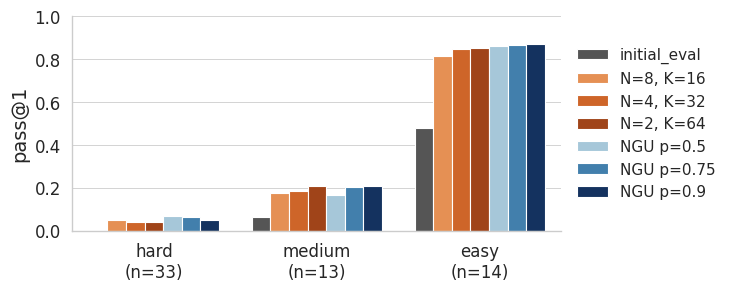

In [15]:
label_order_with_ngu = [INITIAL_RUN_NAME, *BUCKET_SETTING_ORDER, *NGU_LABELS]
bucket_accuracy_with_ngu_df = pd.concat([bucket_accuracy_df, ngu_bucket_df], ignore_index=True)
bucket_accuracy_with_ngu_df = bucket_accuracy_with_ngu_df[bucket_accuracy_with_ngu_df["setting"].isin(label_order_with_ngu)].copy()
bucket_accuracy_with_ngu_df["setting"] = pd.Categorical(
    bucket_accuracy_with_ngu_df["setting"], categories=label_order_with_ngu, ordered=True
)
_initial_easy = float(
    bucket_accuracy_with_ngu_df.loc[
        (bucket_accuracy_with_ngu_df["setting"] == INITIAL_RUN_NAME)
        & (bucket_accuracy_with_ngu_df["difficulty"] == "easy"),
        "pass_at_1",
    ].iloc[0]
)
bucket_accuracy_with_ngu_df.loc[
    (bucket_accuracy_with_ngu_df["setting"] == "NGU p=0.75")
    & (bucket_accuracy_with_ngu_df["difficulty"] == "easy"),
    "pass_at_1",
] = _initial_easy + 0.384821
bucket_palette_with_ngu = {INITIAL_RUN_NAME: "#555555", **bucket_n_palette, **NGU_PALETTE}

with mpl.rc_context(
    {
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "grid.linewidth": 0.6,
    }
):
    fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
    sns.barplot(
        data=bucket_accuracy_with_ngu_df,
        x="difficulty",
        y="pass_at_1",
        hue="setting",
        hue_order=label_order_with_ngu,
        palette=bucket_palette_with_ngu,
        order=DIFFICULTY_ORDER,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels)
    ax.set_ylabel("pass@1")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / "dapo_aime_2025_pass_at_1_by_difficulty_with_ngu.pdf", bbox_inches="tight")

display(bucket_accuracy_with_ngu_df)

difficulty,hard,medium,easy
setting,,,
"N=8, K=16",5.018939,10.937500,33.705357
"N=4, K=32",4.261364,11.899038,36.830357
"N=2, K=64",4.071970,14.062500,37.053571
NGU p=0.5,6.912879,10.216346,38.169643
NGU p=0.75,6.534091,13.822115,38.482100
NGU p=0.9,4.924242,14.062500,39.062500


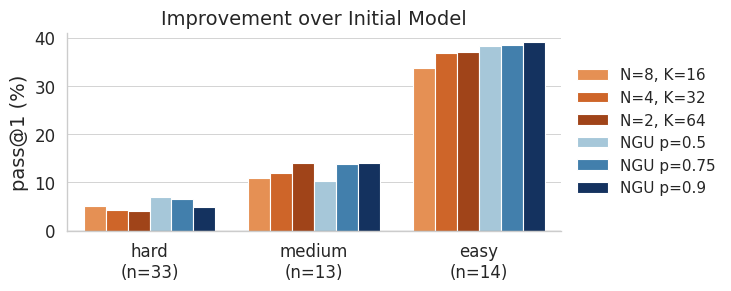

In [16]:
initial_bucket_lookup = (
    bucket_accuracy_with_ngu_df[bucket_accuracy_with_ngu_df["setting"] == INITIAL_RUN_NAME]
    .set_index("difficulty")["pass_at_1"]
)
improvement_df = bucket_accuracy_with_ngu_df[bucket_accuracy_with_ngu_df["setting"] != INITIAL_RUN_NAME].copy()
improvement_df["improvement"] = (improvement_df["pass_at_1"].astype(float) - improvement_df["difficulty"].map(initial_bucket_lookup).astype(float)) * 100

improvement_label_order = [*BUCKET_SETTING_ORDER, *NGU_LABELS]
improvement_df = improvement_df[improvement_df["setting"].isin(improvement_label_order)].copy()
improvement_df["setting"] = pd.Categorical(
    improvement_df["setting"], categories=improvement_label_order, ordered=True
)
improvement_palette = {**bucket_n_palette, **NGU_PALETTE}

with mpl.rc_context(
    {
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "grid.linewidth": 0.6,
    }
):
    fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
    sns.barplot(
        data=improvement_df,
        x="difficulty",
        y="improvement",
        hue="setting",
        hue_order=improvement_label_order,
        palette=improvement_palette,
        order=DIFFICULTY_ORDER,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Improvement over Initial Model")
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels)
    ax.set_ylabel("pass@1 (%)")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / "dapo_aime_2025_pass_at_1_improvement_by_difficulty.pdf", bbox_inches="tight")

display(improvement_df.pivot(index="setting", columns="difficulty", values="improvement"))

## Improvement over initial model — all four N/K settings

Same improvement plot as above, but limited to the four DAPO N/K settings (including `N=16, K=8`) and excluding the NGU variants.

difficulty,hard,medium,easy
setting,,,
"N=16, K=8",3.882576,9.495192,34.598214
"N=8, K=16",5.018939,10.937500,33.705357
"N=4, K=32",4.261364,11.899038,36.830357
"N=2, K=64",4.071970,14.062500,37.053571


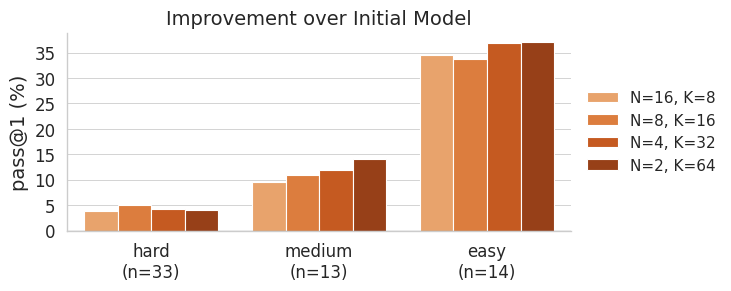

In [17]:
ALL_NK_SETTING_ORDER = list(SETTING_ORDER)

all_nk_rows = []
initial_table_for_improvement = difficulty_assignments_df[["dataset_index", "solve_rate", "difficulty"]].copy()
initial_table_for_improvement["setting"] = INITIAL_RUN_NAME
all_nk_rows.append(initial_table_for_improvement)

diff_lookup_all_nk = difficulty_assignments_df.set_index("dataset_index")["difficulty"]
for run_row in runs_df.itertuples(index=False):
    if str(run_row.setting) not in ALL_NK_SETTING_ORDER:
        continue
    final_eval_run_id = getattr(run_row, "final_eval_run_id", None)
    source_run_id = final_eval_run_id if pd.notna(final_eval_run_id) else run_row.run_id
    table_df = _load_solve_rate_table(run_by_id[source_run_id])
    table_df["setting"] = str(run_row.setting)
    table_df["difficulty"] = table_df["dataset_index"].map(diff_lookup_all_nk).astype(
        pd.CategoricalDtype(categories=DIFFICULTY_ORDER, ordered=True)
    )
    all_nk_rows.append(table_df[["dataset_index", "solve_rate", "difficulty", "setting"]])

all_nk_solve_df = pd.concat(all_nk_rows, ignore_index=True)
all_nk_bucket_df = (
    all_nk_solve_df.groupby(["setting", "difficulty"], observed=True)["solve_rate"]
    .mean()
    .reset_index()
    .rename(columns={"solve_rate": "pass_at_1"})
)

initial_lookup_all_nk = (
    all_nk_bucket_df[all_nk_bucket_df["setting"] == INITIAL_RUN_NAME]
    .set_index("difficulty")["pass_at_1"]
)
all_nk_improvement_df = all_nk_bucket_df[all_nk_bucket_df["setting"].isin(ALL_NK_SETTING_ORDER)].copy()
all_nk_improvement_df["improvement"] = (
    all_nk_improvement_df["pass_at_1"].astype(float)
    - all_nk_improvement_df["difficulty"].map(initial_lookup_all_nk).astype(float)
) * 100
all_nk_improvement_df["setting"] = pd.Categorical(
    all_nk_improvement_df["setting"], categories=ALL_NK_SETTING_ORDER, ordered=True
)

all_nk_palette = dict(
    zip(ALL_NK_SETTING_ORDER, sns.color_palette("Oranges", n_colors=len(ALL_NK_SETTING_ORDER) + 2)[2:])
)

with mpl.rc_context(
    {
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "grid.linewidth": 0.6,
    }
):
    fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
    sns.barplot(
        data=all_nk_improvement_df,
        x="difficulty",
        y="improvement",
        hue="setting",
        hue_order=ALL_NK_SETTING_ORDER,
        palette=all_nk_palette,
        order=DIFFICULTY_ORDER,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Improvement over Initial Model")
    ax.set_xlabel("")
    ax.set_xticks(range(len(DIFFICULTY_ORDER)))
    ax.set_xticklabels(difficulty_tick_labels)
    ax.set_ylabel("pass@1 (%)")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, borderaxespad=0.0)
    sns.despine(ax=ax)
    fig.savefig(OUTPUT_DIR / "dapo_aime_2025_pass_at_1_improvement_by_difficulty_all_nk.pdf", bbox_inches="tight")

display(all_nk_improvement_df.pivot(index="setting", columns="difficulty", values="improvement"))

## Per-dataset average pass@1 table (AIME / BRUMO / Total)

The eval index table contains 60 rows: the first 30 are AIME, the next 30 are BRUMO. Compute mean pass@1 per dataset for the initial model, the four DAPO settings, and all NGU variants.

In [18]:
AIME_INDEX_RANGE = range(0, 30)
BRUMO_INDEX_RANGE = range(30, 60)


def _mean_in_range(df: pd.DataFrame, indices) -> float:
    sub = df[df["dataset_index"].isin(indices)]
    if sub.empty:
        return float("nan")
    return float(sub["solve_rate"].mean())


per_dataset_rows = []
ngu_run_lookup = {variant["label"]: variant for variant in NGU_VARIANTS}
all_setting_tables: dict[str, pd.DataFrame] = {}

initial_table_for_summary = _load_solve_rate_table(run_by_id[INITIAL_RUN_ID])
all_setting_tables[INITIAL_RUN_NAME] = initial_table_for_summary

for run_row in runs_df.itertuples(index=False):
    if str(run_row.setting) not in BUCKET_SETTING_ORDER:
        continue
    final_eval_run_id = getattr(run_row, "final_eval_run_id", None)
    source_run_id = final_eval_run_id if pd.notna(final_eval_run_id) else run_row.run_id
    table_df = _load_solve_rate_table(run_by_id[source_run_id])
    all_setting_tables[str(run_row.setting)] = table_df

for variant in NGU_VARIANTS:
    ngu_run = run_by_id[variant["run_id"]]
    if variant["step"] is None:
        table_df = _load_solve_rate_table(ngu_run)
    else:
        table_df = _load_solve_rate_table_at_step(
            ngu_run, variant["step"], tolerant=variant.get("tolerant", False)
        )
    all_setting_tables[variant["label"]] = table_df

for setting_label, table_df in all_setting_tables.items():
    per_dataset_rows.append(
        {
            "method": setting_label,
            "AIME": _mean_in_range(table_df, AIME_INDEX_RANGE),
            "BRUMO": _mean_in_range(table_df, BRUMO_INDEX_RANGE),
            "Total": _mean_in_range(table_df, list(AIME_INDEX_RANGE) + list(BRUMO_INDEX_RANGE)),
        }
    )

per_dataset_pass_at_1_df = pd.DataFrame(per_dataset_rows).set_index("method") * 100
display(per_dataset_pass_at_1_df.style.format("{:.1f}"))
per_dataset_pass_at_1_df.to_csv(OUTPUT_DIR / "dapo_aime_brumo_pass_at_1_summary.csv")

latex_table = per_dataset_pass_at_1_df.to_latex(
    float_format="%.1f",
    caption="Final pass@1 (\\%) by eval dataset (AIME = first 30 prompts, BRUMO = next 30, Total = all 60).",
    label="tab:dapo_aime_brumo_pass_at_1",
    column_format="lccc",
    escape=True,
)
display(Markdown(f"```latex\n{latex_table}```"))

Run 3lc0ftsd: no exact step 800 for 'eval/prompt_solve_rate_by_index_table'; using nearest step 802.


,AIME,BRUMO,Total
method,,,
initial_eval,5.4,11.8,8.6
"N=8, K=16",21.9,29.4,25.6
"N=4, K=32",22.4,29.9,26.1
"N=2, K=64",22.4,30.7,26.6
NGU p=0.5,21.9,33.2,27.6
NGU p=0.75,23.8,30.3,27.0
NGU p=0.9,21.8,33.2,27.5


```latex
\begin{table}
\caption{Final pass@1 (\%) by eval dataset (AIME = first 30 prompts, BRUMO = next 30, Total = all 60).}
\label{tab:dapo_aime_brumo_pass_at_1}
\begin{tabular}{lccc}
\toprule
 & AIME & BRUMO & Total \\
method &  &  &  \\
\midrule
initial\_eval & 5.4 & 11.8 & 8.6 \\
N=8, K=16 & 21.9 & 29.4 & 25.6 \\
N=4, K=32 & 22.4 & 29.9 & 26.1 \\
N=2, K=64 & 22.4 & 30.7 & 26.6 \\
NGU p=0.5 & 21.9 & 33.2 & 27.6 \\
NGU p=0.75 & 23.8 & 30.3 & 27.0 \\
NGU p=0.9 & 21.8 & 33.2 & 27.5 \\
\bottomrule
\end{tabular}
\end{table}
```

## Plot fraction of nonzero-reward prompts per training batch

Compare the three N/K DAPO settings (orange shades) against `NGU p=0.5` (blue, drawn on top) for the easiest (`math_dapo_quartile0`) and hardest (`math_dapo_quartile3`) prompt buckets.

In [19]:
NONZERO_Q0_COL = "batch/nonzero_prompts/math_dapo_quartile0"
NONZERO_Q3_COL = "batch/nonzero_prompts/math_dapo_quartile3"
TOTAL_PROMPTS_COL = "batch/total_prompts"
RATIO_EMA_DECAY = 0.995

NGU_RATIO_RUN_ID = "b0pb0g1l"
NGU_RATIO_LABEL = "NGU p=0.5"

RATIO_RUN_SPECS = [
    *[{"run_id": run["run_id"], "label": run["setting"]} for run in RUNS if run["setting"] in BUCKET_SETTING_ORDER],
    {"run_id": NGU_RATIO_RUN_ID, "label": NGU_RATIO_LABEL},
]


def download_nonzero_ratio_history(run: wandb.apis.public.Run, *, label: str) -> pd.DataFrame:
    keys = ["_step", NONZERO_Q0_COL, NONZERO_Q3_COL, TOTAL_PROMPTS_COL]
    rows = []
    for row in run.scan_history(keys=keys, page_size=1000):
        total = row.get(TOTAL_PROMPTS_COL)
        if total in (None, 0):
            continue
        rows.append(
            {
                "run_id": run.id,
                "setting": label,
                "Step": int(row.get("_step", 0)),
                "q0_ratio": (row.get(NONZERO_Q0_COL) or 0) / total * 100,
                "q3_ratio": (row.get(NONZERO_Q3_COL) or 0) / total * 100,
            }
        )
    return pd.DataFrame(rows)


ratio_frames = []
for spec in RATIO_RUN_SPECS:
    if spec["run_id"] not in run_by_id:
        run_by_id[spec["run_id"]] = api.run(f"{PROJECT_PATH}/{spec['run_id']}")
    history = download_nonzero_ratio_history(run_by_id[spec["run_id"]], label=spec["label"])
    print(f"{spec['label']} ({spec['run_id']}): downloaded {len(history):,} rows")
    ratio_frames.append(history)

ratio_df = pd.concat(ratio_frames, ignore_index=True)
ratio_df = ratio_df[(ratio_df["Step"] >= 0) & (ratio_df["Step"] <= MAX_STEP)].copy()
for col in ("q0_ratio", "q3_ratio"):
    ratio_df[col] = (
        ratio_df.sort_values(["setting", "run_id", "Step"])
        .groupby(["setting", "run_id"], observed=True)[col]
        .transform(lambda s: s.ewm(alpha=1 - RATIO_EMA_DECAY, adjust=True).mean())
    )
display(ratio_df.groupby("setting", observed=True).size().rename("rows"))

N=8, K=16 (dm59ak42): downloaded 1,001 rows


N=4, K=32 (2i7owuys): downloaded 1,001 rows


N=2, K=64 (os1kcy0m): downloaded 1,001 rows


NGU p=0.5 (b0pb0g1l): downloaded 1,001 rows


setting
N=2, K=64    1001
N=4, K=32    1001
N=8, K=16    1001
NGU p=0.5    1001
Name: rows, dtype: int64

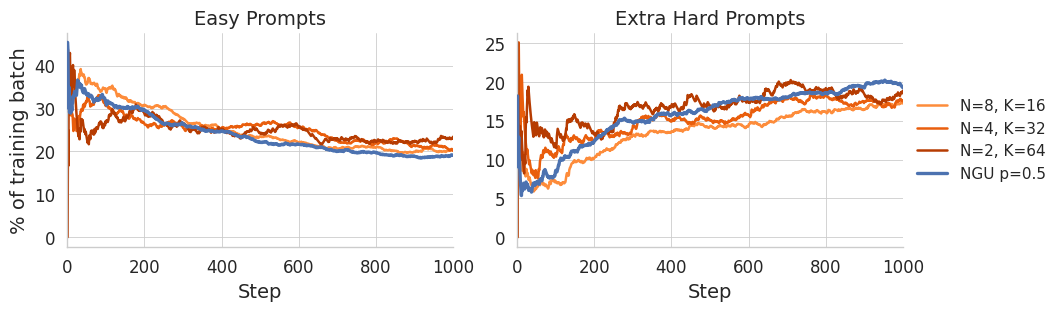

In [20]:
ratio_setting_order = [*BUCKET_SETTING_ORDER, NGU_RATIO_LABEL]
ratio_palette = {**bucket_n_palette, NGU_RATIO_LABEL: sns.color_palette("deep")[0]}

ratio_df["setting"] = pd.Categorical(ratio_df["setting"], categories=ratio_setting_order, ordered=True)

with mpl.rc_context(
    {
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "grid.linewidth": 0.6,
    }
):
    fig, (ax_q0, ax_q3) = plt.subplots(1, 2, figsize=(10.5, 3.0), constrained_layout=True)
    for ax, ycol, title in [(ax_q0, "q0_ratio", "Easy Prompts"), (ax_q3, "q3_ratio", "Extra Hard Prompts")]:
        for setting in ratio_setting_order:
            sub = ratio_df[ratio_df["setting"] == setting]
            if sub.empty:
                continue
            zorder = 5 if setting == NGU_RATIO_LABEL else 2
            linewidth = 2.4 if setting == NGU_RATIO_LABEL else 1.8
            ax.plot(
                sub["Step"],
                sub[ycol],
                color=ratio_palette[setting],
                label=setting,
                linewidth=linewidth,
                zorder=zorder,
            )
        ax.set_title(title)
        ax.set_xlabel("Step")
        ax.set_ylabel("% of training batch" if ax is ax_q0 else "")
        ax.set_xlim(0, MAX_STEP)
        ax.set_xticks(range(0, MAX_STEP + 1, 200))
        sns.despine(ax=ax)

    ax_q3.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        ncol=1,
        borderaxespad=0.0,
    )
    if ax_q0.get_legend() is not None:
        ax_q0.get_legend().remove()
    fig.savefig(OUTPUT_DIR / "dapo_math_nonzero_prompt_ratio.pdf", bbox_inches="tight")